# 📊 Gas Field Simulator - Final Report

In [2]:
import sys, os

# 1. Set the correct working directory (Documents, NOT Desktop)
os.chdir('/Users/jawadalzein/Documents/2nd semestermasters/gas_project')
sys.path.insert(0, os.getcwd())
print(f"📍 Working directory: {os.getcwd()}")

# 2. Clear Jupyter's import cache
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

# 3. Verify src/ folder exists
print(f"📂 src/ contents: {os.listdir('src')}")

# 4. Import all project modules
from src.state import NodeState
from src.interpolator import LinearInterpolator
from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("✅ All imports ready!")

📍 Working directory: /Users/jawadalzein/Documents/2nd semestermasters/gas_project
📂 src/ contents: ['.DS_Store', '__init__.py', '__pycache__', 'simulator.py', 'compressor.py', '.ipynb_checkpoints', 'reservoir.py', 'pipe.py', 'interpolator.py', 'state.py', 'fluid.py', 'well.py']
✅ All imports ready!


### 1. PVT Properties

✅ Imports ready!
Z at 1 atm: 0.998
Z at 50 atm: 0.919
Z at 200 atm: 0.858


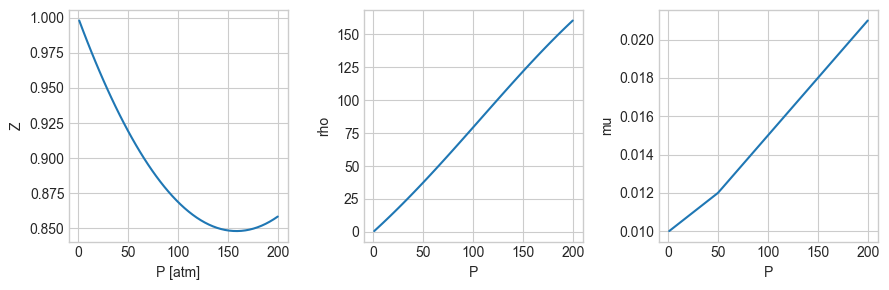

In [3]:
import sys, os
os.chdir('/Users/jawadalzein/Documents/2nd semestermasters/gas_project')
sys.path.insert(0, os.getcwd())

from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("✅ Imports ready!")

# PVT Plot - Z-FACTOR FIXED
M, rho_c, xa, xy, T = 17.5, 160.0, 0.90, 0.10, 310.0
fluid = Fluid(M, rho_c, xa, xy, T)
P = np.linspace(1, 200, 50)

print(f"Z at 1 atm: {fluid.z(1):.3f}")
print(f"Z at 50 atm: {fluid.z(50):.3f}")
print(f"Z at 200 atm: {fluid.z(200):.3f}")

plt.figure(figsize=(9,3))
plt.subplot(131); plt.plot(P, [fluid.z(p) for p in P]); plt.ylabel('Z'); plt.xlabel('P [atm]')
plt.subplot(132); plt.plot(P, [fluid.ro(p) for p in P]); plt.ylabel('rho'); plt.xlabel('P')
plt.subplot(133); plt.plot(P, [fluid.mu(p) for p in P]); plt.ylabel('mu'); plt.xlabel('P')
plt.tight_layout(); plt.show()

### 2. Simulation & Dynamics (180 days)

Simulating: 100%|██████████████████████████| 180/180 [00:00<00:00, 2562.24it/s]


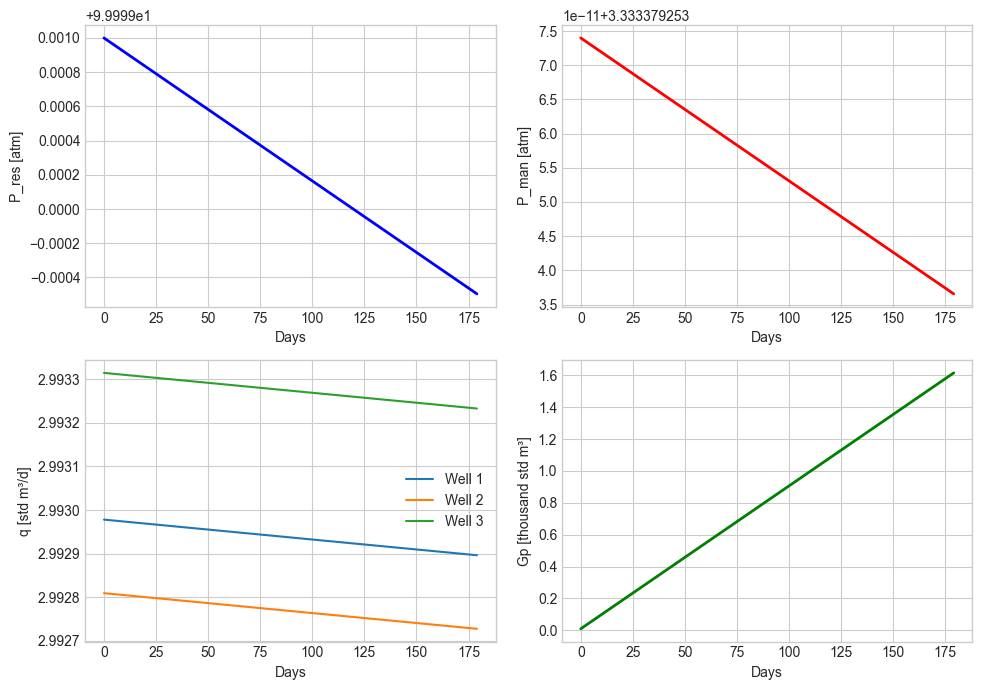

✅ Simulation complete: 179 days


In [4]:
# Simulation & Dynamics (180 days)
res = Reservoir(ResProps(100, 1e6, 310.0), fluid)
shlyf = Pipe(5000, 0.200, 0.000046, fluid, 0.0)
dcs = DCS(1.5, 5.0, 500.0)
wells = [
    Well(fluid, 50, 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
    Well(fluid, 50, 25, 500, 0.1, Pipe(2500, 0.062, 0.000046, fluid, 1900)),
    Well(fluid, 50, 25, 500, 0.1, Pipe(1800, 0.073, 0.000046, fluid, 1600))
]
sim = FieldSimulator(res, wells, shlyf, dcs)
df = sim.run(180, dt=1.0)

# Plot results
fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0,0].plot(df['t'], df['P_res'], 'b-', linewidth=2)
ax[0,0].set_ylabel('P_res [atm]')
ax[0,1].plot(df['t'], df['P_man'], 'r-', linewidth=2)
ax[0,1].set_ylabel('P_man [atm]')
ax[1,0].plot(df['t'], df['q1'], label='Well 1', linewidth=1.5)
ax[1,0].plot(df['t'], df['q2'], label='Well 2', linewidth=1.5)
ax[1,0].plot(df['t'], df['q3'], label='Well 3', linewidth=1.5)
ax[1,0].legend()
ax[1,0].set_ylabel('q [std m³/d]')
ax[1,1].plot(df['t'], df['Gp'], 'g-', linewidth=2)
ax[1,1].set_ylabel('Gp [thousand std m³]')
for a in ax.flatten():
    a.set_xlabel('Days')
    a.grid(True)
plt.tight_layout()
plt.show()
print(f"✅ Simulation complete: {df['t'].max()} days")

### 3. Calibration Metrics

⏳ Calibrating... (this takes a few seconds)


Simulating: 100%|██████████████████████████████| 5/5 [00:00<00:00, 3107.35it/s]


✅ Optimal multipliers: [193.80209147 195.138598   197.8117928 ]


Simulating: 100%|██████████████████████████████| 5/5 [00:00<00:00, 3075.00it/s]


✅ RMSE: 12.6, R²: 0.1379


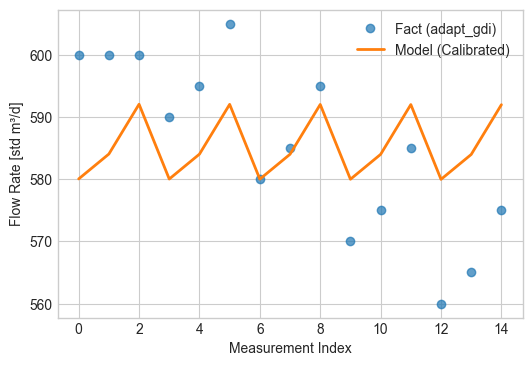

In [5]:
# Calibration Metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Import classes (needed for optimizer to work)
from src.reservoir import ResProps, Reservoir
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator
from src.pipe import Pipe

# Load field data
df_f = pd.read_csv('adapt_gdi_11-2025.csv')
n_days = len(df_f)
q_f = df_f[['q1','q2','q3']].values.flatten()

# Objective function for calibration
def obj(C):
    r = Reservoir(ResProps(100, 1e6, 310.0), fluid)
    w = [
        Well(fluid, 50*C[0], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
        Well(fluid, 50*C[1], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
        Well(fluid, 50*C[2], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800))
    ]
    s = FieldSimulator(r, w, shlyf, DCS(1.5, 5.0, 500.0))
    q_s = s.run(n_days)[['q1','q2','q3']].values.flatten()
    return np.sum((q_f - q_s)**2)

# Run optimizer
print("⏳ Calibrating... (this takes a few seconds)")
opt = minimize(obj, [1, 1, 1], method='Nelder-Mead')
print(f"✅ Optimal multipliers: {opt.x}")

# Final run with best parameters
r_fin = Reservoir(ResProps(100, 1e6, 310.0), fluid)
w_fin = [
    Well(fluid, 50*opt.x[0], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
    Well(fluid, 50*opt.x[1], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
    Well(fluid, 50*opt.x[2], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800))
]
s_fin = FieldSimulator(r_fin, w_fin, shlyf, DCS(1.5, 5.0, 500.0))
q_sim = s_fin.run(n_days)[['q1','q2','q3']].values.flatten()

# Metrics
rmse = np.sqrt(np.mean((q_f - q_sim)**2))
r2 = 1 - np.sum((q_f - q_sim)**2) / np.sum((q_f - np.mean(q_f))**2)
print(f"✅ RMSE: {rmse:.1f}, R²: {r2:.4f}")

# Plot
plt.figure(figsize=(6,4))
plt.plot(q_f, 'o', label='Fact (adapt_gdi)', alpha=0.7)
plt.plot(q_sim, '-', label='Model (Calibrated)', linewidth=2)
plt.xlabel('Measurement Index')
plt.ylabel('Flow Rate [std m³/d]')
plt.legend()
plt.grid(True)
plt.show()